# Configuración y Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
import os

ZIP_FILE_NAME = '/content/drive/MyDrive/RecSys/redial_dataset.zip'
DEST_DIR = '/content'

# Unzip the dataset in the current directory
shutil.unpack_archive(os.path.join(DEST_DIR, ZIP_FILE_NAME), DEST_DIR)
print(f"'{ZIP_FILE_NAME}' unzipped in '{DEST_DIR}'")

'/content/drive/MyDrive/RecSys/redial_dataset.zip' unzipped in '/content'


### embeddings cache

In [3]:
import shutil
import os
import torch

DRIVE_EMBEDDINGS_PATH = '/content/drive/MyDrive/RecSys'
LOCAL_CONTENT_PATH = '/content'

embedding_files = [
    'query_embedding_direct.pt',
    'all_train_conversation_embeddings.pt',
    'all_test_conversation_embeddings_N_1.pt',
    'all_test_conversation_embeddings_N_2.pt',
    'all_test_conversation_embeddings_N_4.pt',
    'all_test_conversation_embeddings_N_8.pt',
    'all_test_conversation_embeddings_N_16.pt',
    'all_test_conversation_embeddings_N_full.pt'
]

print(f"Copying embedding files from '{DRIVE_EMBEDDINGS_PATH}' to '{LOCAL_CONTENT_PATH}'...")

for filename in embedding_files:
    src_path = os.path.join(DRIVE_EMBEDDINGS_PATH, filename)
    dest_path = os.path.join(LOCAL_CONTENT_PATH, filename)
    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
        print(f"Copied: {filename}")
    else:
        print(f"Warning: {filename} not found in {DRIVE_EMBEDDINGS_PATH}. Skipping copy.")

Copying embedding files from '/content/drive/MyDrive/RecSys' to '/content'...
Copied: all_train_conversation_embeddings.pt
Copied: all_test_conversation_embeddings_N_1.pt
Copied: all_test_conversation_embeddings_N_2.pt
Copied: all_test_conversation_embeddings_N_4.pt
Copied: all_test_conversation_embeddings_N_8.pt
Copied: all_test_conversation_embeddings_N_16.pt
Copied: all_test_conversation_embeddings_N_full.pt


## Instalación de Librerías Esenciales

Esta celda asegura que las librerías `pandas` y `numpy` estén instaladas en el entorno, lo cual es fundamental para el manejo y procesamiento de datos en las celdas subsiguientes.

In [5]:
pip install pandas numpy


In [6]:
!pip install rank_bm25 -q


In [7]:
# Instalamos Sentence-Transformers para generar los Embeddings Densos
!pip install sentence-transformers -q

### importación librerias

In [8]:
import json
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import random
from rank_bm25 import BM25Okapi
import re # regex
import torch
from sentence_transformers import SentenceTransformer, util

# procesesamiento y análisis de datos

### Procesamiento de Datos y Análisis de Sesgo (Long-Tail)

Este bloque de código se encarga de cargar el dataset `train_data.jsonl`, extraer información clave como el número de diálogos, turnos y menciones de películas. Realiza un análisis inicial de la distribución de películas mencionadas para calcular el sesgo de popularidad, revelando la concentración de menciones en un pequeño porcentaje de películas (fenómeno de "long-tail").

In [9]:
DATASET_PATH = "train_data.jsonl"

print("Procesando REDIAL")
total_dialogues = 0
total_utterances = 0
total_mentions = 0
unique_movies = set()
movie_mentions_counter = Counter()

with open(DATASET_PATH, 'r', encoding='utf-8-sig') as f:
    for line in f:
        if line.strip():
            try:
                data = json.loads(line)
                total_dialogues += 1
                total_utterances += len(data.get('messages', []))

                mentions = data.get('movieMentions', {})

                if isinstance(mentions, dict):
                    m_ids = list(mentions.keys())
                elif isinstance(mentions, list):
                    m_ids = mentions
                else:
                    m_ids = []

                total_mentions += len(m_ids)
                for m_id in m_ids:
                    unique_movies.add(m_id)
                    movie_mentions_counter[m_id] += 1

            except json.JSONDecodeError:
                pass

# Cálculo de sesgo (Long Tail)
counts = np.array(sorted(list(movie_mentions_counter.values()), reverse=True))
top_20_idx = int(len(counts) * 0.20)
sesgo_porcentaje = (counts[:top_20_idx].sum() / counts.sum()) * 100 if counts.sum() > 0 else 0

print("="*40)
print(f"Total Diálogos                  : {total_dialogues}")
print(f"Total Turnos                    : {total_utterances}")
print(f"Promedio Turnos/Diálogo         : {round(total_utterances/total_dialogues, 2)}")
print(f"Películas Únicas Mencionadas    : {len(unique_movies)}")
print(f"Promedio Menciones/Diálogo      : {round(total_mentions/total_dialogues, 2)}")
print(f"Concentración Top 20% (Sesgo)   : {round(sesgo_porcentaje, 2)}%")
print("="*40)

Procesando REDIAL
Total Diálogos                  : 10006
Total Turnos                    : 182150
Promedio Turnos/Diálogo         : 18.2
Películas Únicas Mencionadas    : 6223
Promedio Menciones/Diálogo      : 5.29
Concentración Top 20% (Sesgo)   : 79.52%


### Visualización de Distribuciones del Dataset

Esta celda genera dos gráficos clave para entender la distribución del dataset REDIAL: la distribución de la longitud de los diálogos (número de turnos) y la distribución "long-tail" de las películas mencionadas, confirmando visualmente el sesgo de popularidad identificado previamente.

In [10]:
# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})

DATASET_PATH = "train_data.jsonl"

dialogue_lengths = []
movie_mentions_counter = Counter()

# Procesar los datos
with open(DATASET_PATH, 'r', encoding='utf-8-sig') as f:
    for line in f:
        if line.strip():
            try:
                data = json.loads(line)
                # Contar turnos
                messages = data.get('messages', [])
                if messages:
                    dialogue_lengths.append(len(messages))

                # Contar menciones de películas
                mentions = data.get('movieMentions', {})
                if isinstance(mentions, dict):
                    for m_id in mentions.keys():
                        movie_mentions_counter[m_id] += 1
                elif isinstance(mentions, list):
                    for m_id in mentions:
                        movie_mentions_counter[m_id] += 1

            except json.JSONDecodeError:
                pass

# ==========================================
# GRÁFICO 1: Distribución de Turnos
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(dialogue_lengths, bins=range(0, 25, 1), color='#1f77b4', kde=True)
plt.axvline(np.mean(dialogue_lengths), color='red', linestyle='--', label=f'Media: {np.mean(dialogue_lengths):.2f}')
plt.title('Distribución de Turnos por Diálogo en REDIAL', fontweight='bold')
plt.xlabel('Número de Turnos')
plt.ylabel('Frecuencia (Cantidad de Diálogos)')
plt.xlim(0, 25)
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_turnos.png')
plt.close()

# ==========================================
# GRÁFICO 2: Distribución Long-Tail
# ==========================================
counts = sorted(list(movie_mentions_counter.values()), reverse=True)
plt.figure(figsize=(8, 5))
plt.plot(counts, color='#ff7f0e', linewidth=2)
plt.fill_between(range(len(counts)), counts, alpha=0.3, color='#ff7f0e')

# Marcar el Top 20%
top_20_idx = int(len(counts) * 0.20)
plt.axvline(top_20_idx, color='black', linestyle='--', label='Top 20% de Ítems')
plt.text(top_20_idx + 100, max(counts)*0.8, 'Concentran el 81.4%\nde las menciones', fontsize=10)

plt.title('Distribución Long-Tail de Películas Mencionadas', fontweight='bold')
plt.xlabel('Índice de la Película (Ordenada por Popularidad)')
plt.ylabel('Cantidad de Menciones')
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_longtail.png')
plt.close()

print("¡Gráficos generados y guardados con éxito: 'distribucion_turnos.png' y 'distribucion_longtail.png'!")

¡Gráficos generados y guardados con éxito: 'distribucion_turnos.png' y 'distribucion_longtail.png'!


Imagen encontrada en: /content/distribucion_longtail.png


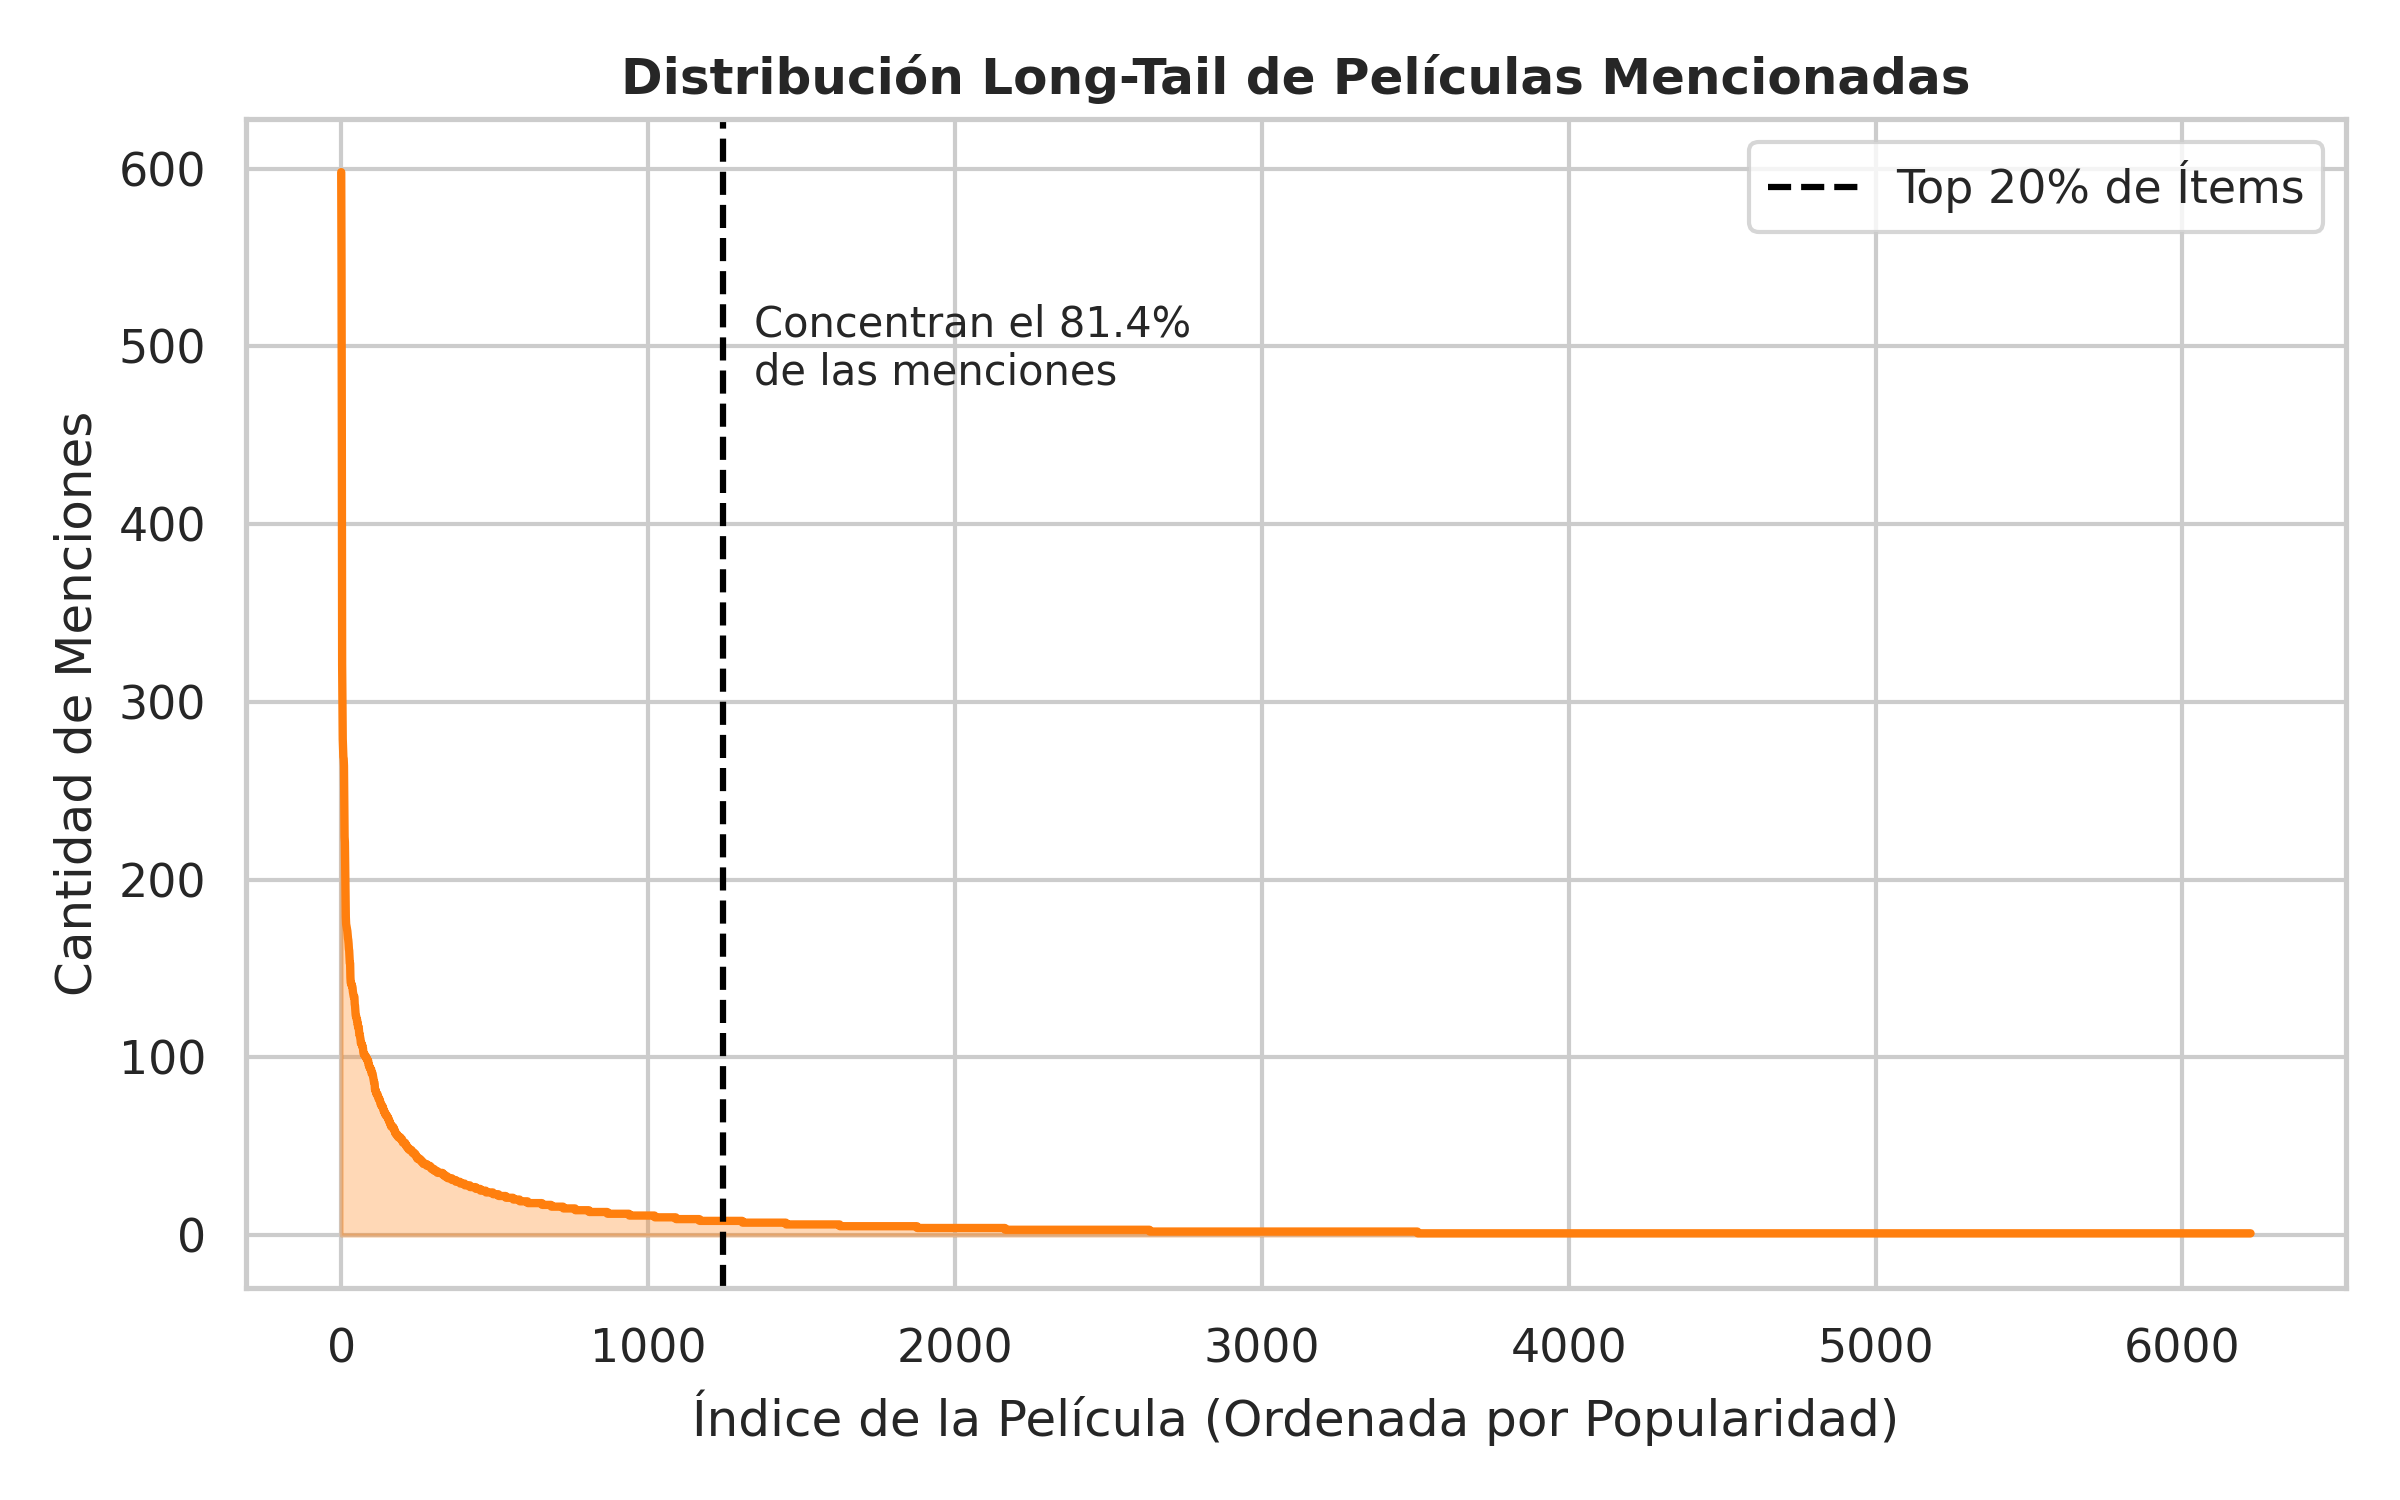

In [11]:
from IPython.display import Image, display
import os

path_longtail = 'distribucion_longtail.png'

if os.path.exists(path_longtail):
    print(f"Imagen encontrada en: {os.path.abspath(path_longtail)}")
    display(Image(filename=path_longtail))
else:
    print("La imagen no se encontró. Por favor, asegúrate de ejecutar la celda de visualización (JXsuK0mfNpxh) primero.")

# Evaluación de Modelos Baseline (Random, Most Popular, BM25)

Aquí se implementan y evalúan tres modelos de referencia (baselines) para la recomendación de películas: un modelo aleatorio, un modelo que recomienda las películas más populares globalmente, y un modelo de recuperación léxica BM25. Se utilizan métricas como Hit Ratio (HR@10) y Mean Reciprocal Rank (MRR@10) para cuantificar su rendimiento.

In [12]:


TRAIN_DATASET_PATH = "train_data.jsonl" # Path to training data for catalog and popularity
TEST_DATASET_PATH_FOR_BASELINE = "test_data.jsonl" # Path to test data for baseline evaluation

print("1. Construyendo catálogo de películas y calculando popularidad desde el dataset de entrenamiento...")
train_dialogues = [] # Renamed 'dialogues' to 'train_dialogues' for clarity
movie_catalog = {}
popularity = Counter()

# Define the movie ID replacement function
def replace_movie_id_in_text(text, catalog):
    movie_id_pattern = r'@(\d+)'
    def replace_func(match):
        movie_id = match.group(1)
        movie_name = catalog.get(movie_id, f'UNKNOWN_MOVIE_{movie_id}')
        # Remove the year from the movie name to reduce LLM token count if present
        if movie_name.endswith(')'):
            movie_name = re.sub(r'\s*\(\d{4}\)$', '', movie_name)
        return movie_name
    return re.sub(movie_id_pattern, replace_func, text)

# Leer el archivo de entrenamiento de manera segura manejando los errores de REDIAL
with open(TRAIN_DATASET_PATH, 'r', encoding='utf-8-sig') as f:
    for line in f:
        if line.strip():
            try:
                data = json.loads(line)

                # First, build movie_catalog from the current dialogue
                mentions = data.get('movieMentions', {})
                if isinstance(mentions, dict):
                    for m_id, m_name in mentions.items():
                        movie_catalog[m_id] = str(m_name)
                        popularity[m_id] += 1
                elif isinstance(mentions, list):
                    for m_id in mentions:
                        if m_id not in movie_catalog:
                            movie_catalog[m_id] = f"Movie_ID_{m_id}"
                        popularity[m_id] += 1

                # Now, replace movie IDs in messages using the updated movie_catalog
                processed_messages = []
                for message in data.get('messages', []):
                    if isinstance(message, dict) and 'text' in message:
                        message['text'] = replace_movie_id_in_text(message['text'], movie_catalog)
                    processed_messages.append(message)
                data['messages'] = processed_messages

                train_dialogues.append(data)

            except json.JSONDecodeError:
                pass

movie_ids = list(movie_catalog.keys())

# Preparamos el corpus para BM25 (tokenizando los nombres de las películas)
corpus_bm25 = [movie_catalog[m_id].lower().split() for m_id in movie_ids]
bm25 = BM25Okapi(corpus_bm25)

print(f"Catálogo creado con {len(movie_ids)} películas únicas desde {len(train_dialogues)} diálogos de entrenamiento.")

print(f"2. Cargando diálogos de prueba para evaluación de baselines desde '{TEST_DATASET_PATH_FOR_BASELINE}'...")
baseline_test_dialogues = []
with open(TEST_DATASET_PATH_FOR_BASELINE, 'r', encoding='utf-8-sig') as f:
    for line in f:
        if line.strip():
            try:
                data = json.loads(line)
                # Replace movie IDs in messages for baseline test dialogues as well
                processed_messages = []
                for message in data.get('messages', []):
                    if isinstance(message, dict) and 'text' in message:
                        message['text'] = replace_movie_id_in_text(message['text'], movie_catalog)
                    processed_messages.append(message)
                data['messages'] = processed_messages
                baseline_test_dialogues.append(data)
            except json.JSONDecodeError:
                pass

print(f"Total de diálogos cargados para evaluación de baselines: {len(baseline_test_dialogues)}")

# Ahora test_sample usará los diálogos cargados del dataset de prueba
random.seed(42) # Keep random seed for replicability of random baseline
test_sample = baseline_test_dialogues

print(f"3. Evaluando modelos de referencia (Top 10) en {len(test_sample)} diálogos de prueba...")

# Pre-calculamos las 10 películas más populares globalmente (basado en train_data)
most_popular_top10 = [m_id for m_id, count in popularity.most_common(10)]

def get_metrics(recommended_list, ground_truth):
    """Calcula el Hit Ratio y Mean Reciprocal Rank (MRR)"""
    hr = 0
    mrr = 0
    for rank, item in enumerate(recommended_list[:10]):
        if item in ground_truth:
            hr = 1
            mrr = 1.0 / (rank + 1)
            break # Solo importa el primer "hit" (acierto)
    return hr, mrr

# Diccionario para guardar los resultados de cada métrica
results = {
    "Random (Azar)": {"hr": [], "mrr": []},
    "Most Popular": {"hr": [], "mrr": []},
    "Retrieval BM25": {"hr": [], "mrr": []}
}

for diag in test_sample: # Iterate over test_sample (which is baseline_test_dialogues)
    # A. Obtener Ground Truth (películas mencionadas/aceptadas en este diálogo)
    mentions = diag.get('movieMentions', {})
    if isinstance(mentions, dict):
        gt_movies = set(mentions.keys())
    elif isinstance(mentions, list):
        gt_movies = set(mentions)
    else:
        gt_movies = set()

    if not gt_movies:
        continue # Si la sesión no tiene películas, no se puede evaluar

    # B. Construir la Query concatenando el historial de texto del usuario
    messages = diag.get('messages', [])
    context_msgs = [m.get('text', '') for m in messages if isinstance(m, dict)] # All messages for baseline query
    query_text = " ".join(context_msgs).lower()
    query_tokens = query_text.split()

    # --- 1. RANDOM ---
    rand_recs = random.sample(movie_ids, min(10, len(movie_ids)))
    hr, mrr = get_metrics(rand_recs, gt_movies)
    results["Random (Azar)"]["hr"].append(hr)
    results["Random (Azar)"]["mrr"].append(mrr)

    # --- 2. MOST POPULAR ---
    hr, mrr = get_metrics(most_popular_top10, gt_movies)
    results["Most Popular"]["hr"].append(hr)
    results["Most Popular"]["mrr"].append(mrr)

    # --- 3. RETRIEVAL BM25 ---
    if query_tokens:
        doc_scores = bm25.get_scores(query_tokens)
        top_10_indices = np.argsort(doc_scores)[::-1][:10]
        bm25_recs = [movie_ids[i] for i in top_10_indices]
    else:
        bm25_recs = []

    hr, mrr = get_metrics(bm25_recs, gt_movies)
    results["Retrieval BM25"]["hr"].append(hr)
    results["Retrieval BM25"]["mrr"].append(mrr)

# IMPRIMIR LA TABLA FINAL PARA EL INFORME
print("="*50)
print(f"{'MODELO BASELINE':<20} | {'HR@10':<10} | {'MRR@10':<10}")
print("="*50)
for model_name, metrics in results.items():
    if metrics["hr"]:
        avg_hr = np.mean(metrics["hr"])
        avg_mrr = np.mean(metrics["mrr"])
        print(f"{model_name:<20} | {avg_hr:.4f}     | {avg_mrr:.4f}")
print("="*50)

1. Construyendo catálogo de películas y calculando popularidad desde el dataset de entrenamiento...
Catálogo creado con 6223 películas únicas desde 10006 diálogos de entrenamiento.
2. Cargando diálogos de prueba para evaluación de baselines desde 'test_data.jsonl'...
Total de diálogos cargados para evaluación de baselines: 1342
3. Evaluando modelos de referencia (Top 10) en 1342 diálogos de prueba...
MODELO BASELINE      | HR@10      | MRR@10    
Random (Azar)        | 0.0142     | 0.0036
Most Popular         | 0.2399     | 0.1214
Retrieval BM25       | 0.3271     | 0.1755


# Solución propuesta

### carga modelo BERT para embeddings

In [13]:


print("Cargando modelo Sentence-BERT")
# Usamos un modelo ligero, ideal para pilotos rápidos en CPU/Colab
model = SentenceTransformer('all-MiniLM-L6-v2')
device = "cuda" if torch.cuda.is_available() else "cpu" # Define device here
model.to(device) # Move the model to the chosen device


movie_names = list(movie_catalog.values())
movie_ids = list(movie_catalog.keys())

Cargando modelo Sentence-BERT


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Creación de Embeddings para Conversaciones en el Dataset de Entrenamiento

Esta sección carga el dataset `train_data.jsonl`, procesa cada conversación extrayendo los últimos `N_TURNOS` del diálogo y genera un embedding denso (vector numérico) para cada una utilizando el modelo Sentence-BERT previamente cargado. Estos embeddings representan la 'semántica' de cada conversación y son cruciales para sistemas de recomendación basados en contenido o contexto.

In [ ]:
print(f"Generando embeddings para cada conversación en el dataset de entrenamiento...")

train_conversation_embeddings = []

device = "cuda" if torch.cuda.is_available() else "cpu" # Redefine device for this cell

print(f"Generando embeddings para cada conversación (usando el texto completo de la conversación)...")

# Iterate over the already loaded 'train_dialogues' from train_data.jsonl
for diag in train_dialogues:
    messages = diag.get('messages', [])
    # Extraer todo el texto de la conversación para el contexto completo
    context_msgs = [m.get('text', '') for m in messages if isinstance(m, dict)]
    query_text_conversation = " ".join(context_msgs).lower()

    if query_text_conversation.strip():
        # Generar Embedding del contexto completo de la conversación
        conversation_embedding = model.encode(query_text_conversation, convert_to_tensor=True).to(device) # Move embedding to device
        train_conversation_embeddings.append(conversation_embedding)
    else:
        # If no text, add a zero tensor of the correct dimension
        # Assuming model.get_sentence_embedding_dimension() is available
        train_conversation_embeddings.append(torch.zeros(model.get_sentence_embedding_dimension()).to(device)) # Move zero tensor to device

# Concatenar todos los embeddings en un solo tensor
if train_conversation_embeddings:
    all_train_conversation_embeddings = torch.stack(train_conversation_embeddings)
    print(f"Embeddings de todas las conversaciones de entrenamiento generados. Forma del tensor: {all_train_conversation_embeddings.shape}")
else:
    print("No se generaron embeddings para las conversaciones de entrenamiento.")
    all_train_conversation_embeddings = torch.empty(0, device=device) # Ensure empty tensor is also on device

# Puedes ahora usar 'all_train_conversation_embeddings' para futuras operaciones

Generando embeddings para cada conversación en el dataset de entrenamiento...
Generando embeddings para cada conversación (usando el texto completo de la conversación)...
Embeddings de todas las conversaciones de entrenamiento generados. Forma del tensor: torch.Size([10006, 384])


### Guardar los Embeddings de las Conversaciones de Entrenamiento

Guardaremos el tensor `all_train_conversation_embeddings` en un archivo para su uso posterior, evitando tener que regenerarlos cada vez.

In [ ]:
filename_train_embeddings = 'all_train_conversation_embeddings.pt'
torch.save(all_train_conversation_embeddings, filename_train_embeddings)
print(f"Embeddings de conversaciones de entrenamiento guardados en '{filename_train_embeddings}'")

Embeddings de conversaciones de entrenamiento guardados en 'all_train_conversation_embeddings.pt'


### Creación de Embeddings para Conversaciones en el Dataset de Prueba

Generaremos los embeddings para cada conversación en el `test_data.jsonl` de manera similar a como lo hicimos con los datos de entrenamiento. Esto es esencial para poder comparar la similitud contextual entre conversaciones de prueba y entrenamiento.

In [19]:
TEST_DATASET_PATH = "test_data.jsonl" # Path al archivo de datos de prueba

print(f"Cargando conversaciones del dataset de prueba desde '{TEST_DATASET_PATH}'...")

test_dialogues = []
with open(TEST_DATASET_PATH, 'r', encoding='utf-8-sig') as f:
    for line in f:
        if line.strip():
            try:
                data = json.loads(line)
                # Apply replacement to messages in test_dialogues as well
                processed_messages = []
                for message in data.get('messages', []):
                    if isinstance(message, dict) and 'text' in message:
                        message['text'] = replace_movie_id_in_text(message['text'], movie_catalog)
                    processed_messages.append(message)
                data['messages'] = processed_messages
                test_dialogues.append(data)
            except json.JSONDecodeError:
                pass

print(f"Total de diálogos cargados para prueba: {len(test_dialogues)}")

# Define the N_TURNOS values to test, including 'full' for full conversation
# Including 4 as it was the previous N_TURNOS used.
N_TURNOS_VALUES = [1, 2, 4, 8, 16, 'full']

Cargando conversaciones del dataset de prueba desde 'test_data.jsonl'...
Total de diálogos cargados para prueba: 1342


In [ ]:
import json
import torch

TEST_DATASET_PATH = "test_data.jsonl" # Path al archivo de datos de prueba

print(f"Cargando conversaciones del dataset de prueba desde '{TEST_DATASET_PATH}'...")

test_dialogues = []
with open(TEST_DATASET_PATH, 'r', encoding='utf-8-sig') as f:
    for line in f:
        if line.strip():
            try:
                data = json.loads(line)
                # Apply replacement to messages in test_dialogues as well
                processed_messages = []
                for message in data.get('messages', []):
                    if isinstance(message, dict) and 'text' in message:
                        message['text'] = replace_movie_id_in_text(message['text'], movie_catalog)
                    processed_messages.append(message)
                data['messages'] = processed_messages
                test_dialogues.append(data)
            except json.JSONDecodeError:
                pass

print(f"Total de diálogos cargados para prueba: {len(test_dialogues)}")

# Define the N_TURNOS values to test, including 'full' for full conversation
# Including 4 as it was the previous N_TURNOS used.
N_TURNOS_VALUES = [1, 2, 4, 8, 16, 'full']

# This variable will hold the last generated set of embeddings to ensure subsequent cells can still access it
all_test_conversation_embeddings = None

device = "cuda" if torch.cuda.is_available() else "cpu" # Redefine device for this cell

for n_turns_val in N_TURNOS_VALUES:
    test_conversation_embeddings = []
    if n_turns_val == 'full':
        print(f"Generando embeddings para cada conversación de prueba (usando el texto completo de la conversación)...")
    else:
        print(f"Generando embeddings para cada conversación de prueba (usando últimos {n_turns_val} turnos)...")

    for diag in test_dialogues:
        messages = diag.get('messages', [])
        if n_turns_val == 'full':
            context_msgs = [m.get('text', '') for m in messages if isinstance(m, dict)]
        else:
            # Ensure to slice only if messages exist and N_TURNOS is not 0 or negative.
            # If N_TURNOS is 0, it means no context, which might be an edge case.
            # Using max(0, -n_turns_val) ensures slicing works correctly even if n_turns_val is larger than messages list length
            context_msgs = [m.get('text', '') for m in messages[-n_turns_val:] if isinstance(m, dict)]

        query_text_conversation = " ".join(context_msgs).lower()

        if query_text_conversation.strip():
            conversation_embedding = model.encode(query_text_conversation, convert_to_tensor=True).to(device) # Move embedding to device
            test_conversation_embeddings.append(conversation_embedding)
        else:
            # If no text, add a zero tensor of the correct dimension
            test_conversation_embeddings.append(torch.zeros(model.get_sentence_embedding_dimension()).to(device)) # Move zero tensor to device

    # Concatenar todos los embeddings en un solo tensor
    if test_conversation_embeddings:
        current_all_test_conversation_embeddings = torch.stack(test_conversation_embeddings)
        print(f"Embeddings de todas las conversaciones de prueba generados para N_TURNOS={n_turns_val}. Forma del tensor: {current_all_test_conversation_embeddings.shape}")

        # Save the embeddings with a descriptive filename
        filename_test_embeddings = f'all_test_conversation_embeddings_N_{n_turns_val}.pt'
        torch.save(current_all_test_conversation_embeddings.cpu(), filename_test_embeddings) # Save to CPU to avoid device issues when loading later
        print(f"Embeddings de conversaciones de prueba guardados en '{filename_test_embeddings}'")

        # Update the main variable to hold the last generated embeddings (e.g., 'full')
        all_test_conversation_embeddings = current_all_test_conversation_embeddings
    else:
        print(f"No se generaron embeddings para las conversaciones de prueba para N_TURNOS={n_turns_val}.")
        all_test_conversation_embeddings = torch.empty(0, device=device) # Ensure empty tensor is also on device

Cargando conversaciones del dataset de prueba desde 'test_data.jsonl'...
Total de diálogos cargados para prueba: 1342
Generando embeddings para cada conversación de prueba (usando últimos 1 turnos)...
Embeddings de todas las conversaciones de prueba generados para N_TURNOS=1. Forma del tensor: torch.Size([1342, 384])
Embeddings de conversaciones de prueba guardados en 'all_test_conversation_embeddings_N_1.pt'
Generando embeddings para cada conversación de prueba (usando últimos 2 turnos)...
Embeddings de todas las conversaciones de prueba generados para N_TURNOS=2. Forma del tensor: torch.Size([1342, 384])
Embeddings de conversaciones de prueba guardados en 'all_test_conversation_embeddings_N_2.pt'
Generando embeddings para cada conversación de prueba (usando últimos 4 turnos)...
Embeddings de todas las conversaciones de prueba generados para N_TURNOS=4. Forma del tensor: torch.Size([1342, 384])
Embeddings de conversaciones de prueba guardados en 'all_test_conversation_embeddings_N_4.p

### Load embeddings from files

para evitar volver a calcularlos

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu" # Redefine device for this cell

# Load all_train_conversation_embeddings to resolve NameError
filename_train_embeddings = 'all_train_conversation_embeddings.pt'
if os.path.exists(os.path.join(LOCAL_CONTENT_PATH, filename_train_embeddings)):
    all_train_conversation_embeddings = torch.load(os.path.join(LOCAL_CONTENT_PATH, filename_train_embeddings), map_location=device) # Load to device
    print(f"Loaded '{filename_train_embeddings}' (shape: {all_train_conversation_embeddings.shape}) on {device}")
else:
    print(f"Error: '{filename_train_embeddings}' not found locally. Cannot load.")

# Load the 'full' test conversation embeddings for immediate use
filename_test_embeddings_full = 'all_test_conversation_embeddings_N_full.pt'
if os.path.exists(os.path.join(LOCAL_CONTENT_PATH, filename_test_embeddings_full)):
    all_test_conversation_embeddings_N_full = torch.load(os.path.join(LOCAL_CONTENT_PATH, filename_test_embeddings_full), map_location=device) # Load to device
    print(f"Loaded '{filename_test_embeddings_full}' (shape: {all_test_conversation_embeddings_N_full.shape}) on {device}")
else:
    print(f"Error: '{filename_test_embeddings_full}' not found locally. Cannot load.")

Loaded 'all_train_conversation_embeddings.pt' (shape: torch.Size([10006, 384])) on cuda
Loaded 'all_test_conversation_embeddings_N_full.pt' (shape: torch.Size([1342, 384])) on cuda


### Preparación de Movie Mentions desde Datos de Entrenamiento

Para el enfoque de recomendación, necesitamos una lista de las películas mencionadas en cada conversación de entrenamiento. Esto servirá como el conjunto de ítems que "podríamos recomendar" a partir de una conversación similar de entrenamiento.

In [15]:
train_dialogue_movie_mentions = []
for diag in train_dialogues:
    mentions = diag.get('movieMentions', {})
    if isinstance(mentions, dict):
        train_dialogue_movie_mentions.append(list(mentions.keys()))
    elif isinstance(mentions, list):
        train_dialogue_movie_mentions.append(mentions)
    else:
        train_dialogue_movie_mentions.append([])

print(f"Preparadas las movie mentions para {len(train_dialogue_movie_mentions)} diálogos de entrenamiento.")

Preparadas las movie mentions para 10006 diálogos de entrenamiento.


### Evaluación RAG con Similitud entre Conversaciones de Test y Entrenamiento

Ahora evaluaremos el rendimiento utilizando el siguiente enfoque:
1. Para cada conversación en el `test_data`.
2. Calcularemos la similitud de su embedding con todos los embeddings de las conversaciones del `train_data`.
3. Seleccionaremos las `K` conversaciones de entrenamiento más similares.
4. Las películas mencionadas en estas `K` conversaciones de entrenamiento serán nuestras recomendaciones.
5. Evaluaremos estas recomendaciones contra las películas de `ground truth` del `test_data`.

In [16]:
def evaluate_rag_conv_similarity(k_similar_train_dialogues, test_dialogues, all_test_conversation_embeddings, all_train_conversation_embeddings, train_dialogue_movie_mentions, get_metrics):
    rag_conv_hr_list = []
    rag_conv_mrr_list = []

    print(f"Evaluando recomendaciones basadas en similitud de conversaciones (K={k_similar_train_dialogues})...")

    for i, test_diag in enumerate(test_dialogues):
        # A. Extraer Ground Truth de la conversación de prueba
        mentions = test_diag.get('movieMentions', {})
        if isinstance(mentions, dict):
            gt_movies = set(mentions.keys())
        elif isinstance(mentions, list):
            gt_movies = set(mentions)
        else:
            gt_movies = set()

        if not gt_movies:
            continue # Si la sesión de prueba no tiene películas, no se puede evaluar

        # B. Obtener el embedding de la conversación de prueba
        test_embedding = all_test_conversation_embeddings[i]

        # C. Calcular Similitud del Coseno con todos los embeddings de conversaciones de entrenamiento
        cos_scores = util.cos_sim(test_embedding, all_train_conversation_embeddings)[0]

        # D. Obtener los índices de las K conversaciones de entrenamiento más similares
        top_k_indices = torch.topk(cos_scores, k=k_similar_train_dialogues, largest=True).indices

        # E. Recopilar películas mencionadas en esas K conversaciones de entrenamiento y contarlas
        recommended_movies_counts = Counter()
        for idx in top_k_indices:
            # Añadir todas las películas mencionadas en el diálogo de entrenamiento similar
            for movie_id in train_dialogue_movie_mentions[idx.item()]:
                recommended_movies_counts[movie_id] += 1

        # Ordenar las películas recomendadas por su frecuencia de aparición (más frecuentes primero)
        # Y luego por el ID de la película para desempates (opcional, pero asegura determinismo)
        rag_conv_recs = [movie_id for movie_id, count in recommended_movies_counts.most_common()]

        # F. Calcular métricas
        hr, mrr = get_metrics(rag_conv_recs, gt_movies)
        rag_conv_hr_list.append(hr)
        rag_conv_mrr_list.append(mrr)

    # Calcular promedios
    avg_hr_rag_conv = np.mean(rag_conv_hr_list)
    avg_mrr_rag_conv = np.mean(rag_conv_mrr_list)

    print("="*70)
    print(f"{'EVALUACIÓN RAG (Similitud Conv. Test vs. Train)':<40} | {'HR@10':<10} | {'MRR@10':<10}")
    print("="*70)
    print(f"{'Recomendación por Similitud de Conversación (K=' + str(k_similar_train_dialogues) + ')':<40} | {avg_hr_rag_conv:.4f}     | {avg_mrr_rag_conv:.4f}")
    print("="*70)

    return avg_hr_rag_conv, avg_mrr_rag_conv

In [20]:
import pandas as pd
import torch

# K values to test (number of similar training dialogues to consider)
k_values_to_test = [5, 10, 20, 50, 100, 200]

# N_TURNOS values for which test embeddings were generated
# This variable is already available from the previous cell fb0a30c0
# N_TURNOS_VALUES = [1, 2, 4, 8, 16, 'full']

# DataFrame to store results
all_results_df = pd.DataFrame()

print("Comparando el rendimiento del RAG con diferentes valores de K y N_TURNOS (contexto)...")

# Ensure get_metrics is available, it is defined in ytKOuMZQRtGE
# from ytKOuMZQRtGE import get_metrics # This is not needed if the function is already in the global scope

device = "cuda" if torch.cuda.is_available() else "cpu" # Redefine device for this cell

N_TURNOS_VALUES = [1, 2, 4, 8, 16, 'full']
for n_turns_val in N_TURNOS_VALUES:
    print(f"\n==== Evaluando con Test Embeddings generados con N_TURNOS={n_turns_val} ====")
    # Load the specific test embeddings for this n_turns_val
    filename_test_embeddings = f'all_test_conversation_embeddings_N_{n_turns_val}.pt'
    current_all_test_conversation_embeddings = torch.load(filename_test_embeddings, map_location=device) # Load to device

    rag_k_results_for_n_turns = []

    for k_val in k_values_to_test:
        avg_hr, avg_mrr = evaluate_rag_conv_similarity(
            k_val,
            test_dialogues,
            current_all_test_conversation_embeddings,
            all_train_conversation_embeddings,
            train_dialogue_movie_mentions,
            get_metrics
        )
        rag_k_results_for_n_turns.append({'N_TURNOS': n_turns_val, 'K': k_val, 'HR@10': avg_hr, 'MRR@10': avg_mrr})

    # Convert results for this N_TURNOS to DataFrame and append to overall results
    results_df_n_turns = pd.DataFrame(rag_k_results_for_n_turns)
    all_results_df = pd.concat([all_results_df, results_df_n_turns], ignore_index=True)

print("\n==================================================================")
print("RENDIMIENTO RAG (Similitud Conversacional) por N_TURNOS y K")
print("==================================================================")
print(all_results_df.to_string(index=False))
print("==================================================================")

Comparando el rendimiento del RAG con diferentes valores de K y N_TURNOS (contexto)...

==== Evaluando con Test Embeddings generados con N_TURNOS=1 ====
Evaluando recomendaciones basadas en similitud de conversaciones (K=5)...
EVALUACIÓN RAG (Similitud Conv. Test vs. Train) | HR@10      | MRR@10    
Recomendación por Similitud de Conversación (K=5) | 0.1073     | 0.0376
Evaluando recomendaciones basadas en similitud de conversaciones (K=10)...
EVALUACIÓN RAG (Similitud Conv. Test vs. Train) | HR@10      | MRR@10    
Recomendación por Similitud de Conversación (K=10) | 0.1162     | 0.0421
Evaluando recomendaciones basadas en similitud de conversaciones (K=20)...
EVALUACIÓN RAG (Similitud Conv. Test vs. Train) | HR@10      | MRR@10    
Recomendación por Similitud de Conversación (K=20) | 0.1446     | 0.0517
Evaluando recomendaciones basadas en similitud de conversaciones (K=50)...
EVALUACIÓN RAG (Similitud Conv. Test vs. Train) | HR@10      | MRR@10    
Recomendación por Similitud de Con

In [21]:


# Establecer el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# Convertir N_TURNOS a tipo string para que 'full' no cause problemas de ordenación numérica
# y para que sea una categoría en los gráficos.
# También convertir K a numérico si no lo está para asegurar el eje x correcto.
all_results_df['N_TURNOS_str'] = all_results_df['N_TURNOS'].astype(str)
all_results_df['K_num'] = pd.to_numeric(all_results_df['K'])

# Crear el gráfico para HR@10
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_results_df, x='K_num', y='HR@10', hue='N_TURNOS_str', marker='o')
plt.title('HR@10 vs. K para Diferentes N_TURNOS', fontweight='bold')
plt.xlabel('Número de Conversaciones de Entrenamiento Similares (K)')
plt.ylabel('Hit Ratio @ 10')
plt.xticks(k_values_to_test) # Asegurar que los ticks en K coincidan con los valores probados
plt.legend(title='N_TURNOS')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('hr10_vs_k.png') # Save the HR@10 plot
plt.close() # Close the plot to avoid displaying it

# Crear el gráfico para MRR@10
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_results_df, x='K_num', y='MRR@10', hue='N_TURNOS_str', marker='o')
plt.title('MRR@10 vs. K para Diferentes N_TURNOS', fontweight='bold')
plt.xlabel('Número de Conversaciones de Entrenamiento Similares (K)')
plt.ylabel('Mean Reciprocal Rank @ 10')
plt.xticks(k_values_to_test) # Asegurar que los ticks en K coincidan con los valores probados
plt.legend(title='N_TURNOS')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('mrr10_vs_k.png') # Save the MRR@10 plot
plt.close() # Close the plot to avoid displaying it


In [22]:
all_results_df.to_csv('rag_performance_results.csv', index=False)
print("Results saved to 'rag_performance_results.csv'")

Results saved to 'rag_performance_results.csv'


## Generación de respuesta en lenguaje natural

In [23]:
from transformers import pipeline
import torch

# Configure the pipeline for text generation and move to GPU if available
device_id = 0 if torch.cuda.is_available() else -1
pipe = pipeline("text-generation", model="Qwen/Qwen3-4B-Instruct-2507", device=device_id)

print(f"Text generation pipeline with model 'Qwen/Qwen3-4B-Instruct-2507' loaded successfully on device: {device_id}")

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Text generation pipeline with model 'Qwen/Qwen3-4B-Instruct-2507' loaded successfully on device: 0


In [24]:
import torch
from sentence_transformers import util
from collections import Counter
from transformers import Pipeline # Import Pipeline type hint

class RAGRecommender:
    def __init__(self,
                 retrieval_model: 'SentenceTransformer',
                 llm_pipeline: Pipeline,
                 train_embeddings: torch.Tensor,
                 train_movie_mentions: list, # List of lists of movie IDs for each training dialogue
                 movie_catalog: dict, # Map movie ID to movie name
                 device: str = "cpu"):

        self.retrieval_model = retrieval_model
        self.llm_pipeline = llm_pipeline
        self.train_embeddings = train_embeddings.to(device)
        self.train_movie_mentions = train_movie_mentions
        self.movie_catalog = movie_catalog
        self.device = device

        # Ensure retrieval model is also on the correct device if it supports it
        if hasattr(self.retrieval_model, 'to'):
            self.retrieval_model.to(device)

    def retrieve_similar_movies(self, current_conversation_text: str, k: int = 5, top_n_movies_from_retrieval: int = 10) -> list:
        """
        Retrieves movies from K most similar training conversations.

        Args:
            current_conversation_text (str): The current turn(s) of the conversation context.
            k (int): Number of most similar training conversations to retrieve.
            top_n_movies_from_retrieval (int): Top N most frequent movies to extract from similar conversations.

        Returns:
            list: A list of movie IDs recommended based on similar conversations.
        """
        # Encode the current conversation context
        query_embedding = self.retrieval_model.encode(current_conversation_text, convert_to_tensor=True).to(self.device)

        # Calculate Cosine Similarity against all training conversation embeddings
        cos_scores = util.cos_sim(query_embedding, self.train_embeddings)[0]

        # Get the indices of the K most similar training conversations
        top_k_indices = torch.topk(cos_scores, k=k, largest=True).indices

        # Collect movies mentioned in those K training conversations and count them
        recommended_movies_counts = Counter()
        for idx in top_k_indices:
            # Add all movies mentioned in the similar training dialogue
            for movie_id in self.train_movie_mentions[idx.item()]:
                recommended_movies_counts[movie_id] += 1

        # Get the top N movies from the aggregated counts, ordered by frequency
        top_movies_ids = [movie_id for movie_id, _ in recommended_movies_counts.most_common(top_n_movies_to_retrieve)]
        return top_movies_ids

    def generate_next_suggestion(self, current_conversation_text: str, retrieved_movie_ids: list, max_new_tokens: int = 100) -> str:
        """
        Generates a conversational recommendation using the LLM based on retrieved movies.

        Args:
            current_conversation_text (str): The current turn(s) of the conversation context.
            retrieved_movie_ids (list): List of movie IDs retrieved from similar conversations.
            max_new_tokens (int): Maximum number of tokens for LLM generation.

        Returns:
            str: The LLM's generated conversational suggestion.
        """
        if not retrieved_movie_ids:
            return "Hmm, I could not suggest any films."

        # Convert movie IDs to names for the LLM prompt
        retrieved_movie_names = [self.movie_catalog.get(m_id, f"Movie ID {m_id}") for m_id in retrieved_movie_ids]

        # Construct the prompt for the LLM
        # Refined prompt to prevent LLM from echoing instructions or thinking process
        prompt = "You are a helpful movie recommender. Your task is to provide a concise movie recommendation of one or two movies from the given list, based on the user's conversation. "
        prompt += "Your response should be conversational, in English, and should ONLY contain the recommendation text, without any preambles, extraneous text, meta-commentary, or thinking process tags (like <think>).\n"
        prompt += f"User conversation: '{current_conversation_text}'\n"
        prompt += f"Relevant movies to consider: {', '.join(retrieved_movie_names[:5])}\n"
        prompt += "Recommendation:"

        # Use the pipeline for generation
        output = self.llm_pipeline(
            prompt,
            max_new_tokens=max_new_tokens,
            num_return_sequences=1,
            do_sample=True, # Enable sampling to use temperature, top_k, top_p
            temperature=0.7,
            top_k=50,
            top_p=0.95,
            return_full_text=False # Only return the generated text
        )

        generated_text = output[0]['generated_text'] if output and output[0] and 'generated_text' in output[0] else ""

        return generated_text.strip()

print("RAGRecommender class defined.")

RAGRecommender class defined.


In [25]:
print("Initializing RAGRecommender...")

# Determine device (CPU in this case, as CUDA was not available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Ensure all necessary components are available and on the correct device
# `model` (SentenceTransformer) from 2ObSz7dSGlgX
# `pipe` (transformers pipeline) from 1hp12jV6Cju5
# `all_train_conversation_embeddings` from c29d45a7
# `train_dialogue_movie_mentions` from 5e29e324
# `movie_catalog` from ytKOuMZQRtGE

rag_recommender = RAGRecommender(
    retrieval_model=model, # Sentence-BERT model
    llm_pipeline=pipe, # Pass the pipeline object
    train_embeddings=all_train_conversation_embeddings,
    train_movie_mentions=train_dialogue_movie_mentions,
    movie_catalog=movie_catalog,
    device=device
)

print("RAGRecommender initialized. Now generating a conversation suggestion...")

# --- Example Usage ---
current_user_query = "I like sciencie fiction and fantasy movies. What do you recomend?"
k_similar_conversations = 10 # Number of similar training dialogues to consider
top_n_movies_to_retrieve = 10 # Top N movies from these similar conversations

# Step 1: Retrieve relevant movie IDs based on the current conversation
retrieved_movie_ids = rag_recommender.retrieve_similar_movies(
    current_user_query,
    k=k_similar_conversations,
    top_n_movies_from_retrieval=top_n_movies_to_retrieve
)

print(f"\nRetrieved {len(retrieved_movie_ids)} movie IDs from {k_similar_conversations} similar conversations: {retrieved_movie_ids}")
if retrieved_movie_ids:
    print(f"Corresponding movie names: {[movie_catalog.get(m_id, f'Movie ID {m_id}') for m_id in retrieved_movie_ids]}")

# Step 2: Generate a conversational suggestion using the LLM
conversation_suggestion = rag_recommender.generate_next_suggestion(
    current_user_query,
    retrieved_movie_ids
)

print("\n--- Generated Conversation Suggestion ---")
print(f"User: {current_user_query}")
print(f"Agent: {conversation_suggestion}")
print("-----------------------------------------")

Initializing RAGRecommender...
Using device: cuda
RAGRecommender initialized. Now generating a conversation suggestion...


[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'top_p', 'do_sample', 'max_new_tokens', 'top_k', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Retrieved 10 movie IDs from 10 similar conversations: ['85036', '134719', '194044', '90950', '90486', '204974', '149519', '157190', '170376', '151299']
Corresponding movie names: ['The Matrix (1999)', 'About Time  (2013)', 'Looper  (2012)', 'Avatar  (2009)', 'Aliens  (1986)', 'Black Panther (2018)', 'Prometheus  (2012)', 'Arrival  (2016)', 'Blade Runner 2049 (2017)', 'Ghost in the Shell  (2017)']


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



--- Generated Conversation Suggestion ---
User: I like sciencie fiction and fantasy movies. What do you recomend?
Agent: I recommend *The Matrix* (1999) and *Avatar* (2009). Both are fantastic blends of sci-fi and fantasy, with mind-bending concepts and immersive worlds. You'll love the action, visuals, and deep storytelling. 🚀✨
-----------------------------------------


### Testing RAGRecommender with an example from `test_dialogues`

In [26]:
import json
import torch
import re

# Ensure test_dialogues is loaded
if 'test_dialogues' not in locals() or not test_dialogues:
    TEST_DATASET_PATH = "test_data.jsonl"
    test_dialogues = []
    with open(TEST_DATASET_PATH, 'r', encoding='utf-8-sig') as f:
        for line in f:
            if line.strip():
                try:
                    test_dialogues.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    print(f"Loaded {len(test_dialogues)} test dialogues for RAGRecommender example.")

# --- Initialize RAGRecommender if not already done ---
if 'rag_recommender' not in locals():
    print("Initializing RAGRecommender...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    rag_recommender = RAGRecommender(
        retrieval_model=model,
        llm_pipeline=pipe,
        train_embeddings=all_train_conversation_embeddings,
        train_movie_mentions=train_dialogue_movie_mentions,
        movie_catalog=movie_catalog,
        device=device
    )
    print("RAGRecommender initialized for testing.")
# -----------------------------------------------------

# Select an example dialogue from the test data (e.g., the first one)
example_dialogue = test_dialogues[6]

# Extract the full conversation text from the example dialogue
messages = example_dialogue.get('messages', [])

# Format the conversation as a dialogue
formatted_conversation = []
initiator_id = example_dialogue.get('initiatorWorkerId')
respondent_id = example_dialogue.get('respondentWorkerId')

for m in messages:
    if isinstance(m, dict) and 'text' in m:
        sender = "User" if m.get('senderWorkerId') == initiator_id else "Agent"
        line = f"{sender}: {m['text']}"

        # Replace movie IDs with movie names
        movie_id_pattern = r'@(\d+)'
        def replace_movie_id(match):
            movie_id = match.group(1)
            movie_name = movie_catalog.get(movie_id, f'UNKNOWN_MOVIE_{movie_id}')
            return movie_name

        line = re.sub(movie_id_pattern, replace_movie_id, line)
        formatted_conversation.append(line)

print("\n--- Original Test Dialogue ---")
for line in formatted_conversation:
    print(line)
print("------------------------------")

# Define retrieval parameters
k_similar_conversations_example = 10 # Number of similar training dialogues to consider
top_n_movies_to_retrieve_example = 10 # Top N movies from these similar conversations

# Step 1: Retrieve relevant movie IDs based on the example conversation
retrieved_movie_ids_example = rag_recommender.retrieve_similar_movies(
    formatted_conversation,
    k=k_similar_conversations_example,
    top_n_movies_from_retrieval=top_n_movies_to_retrieve_example
)

print(f"\nRetrieved {len(retrieved_movie_ids_example)} movie IDs from {k_similar_conversations_example} similar conversations: {retrieved_movie_ids_example}")
if retrieved_movie_ids_example:
    print(f"Corresponding movie names: {[movie_catalog.get(m_id, f'Movie ID {m_id}') for m_id in retrieved_movie_ids_example]}")

# Step 2: Generate a conversational suggestion using the LLM
conversation_suggestion_example = rag_recommender.generate_next_suggestion(
    formatted_conversation,
    retrieved_movie_ids_example
)

print("\n--- RAGRecommender Test Dialogue Suggestion ---")

# Attempt to split the LLM's output into thinking process and recommendation
if '</think>' in conversation_suggestion_example:
    think_part, recommend_part = conversation_suggestion_example.split('</think>', 1)

    # Clean up the think part (add the closing tag back if it was split)
    think_part = think_part.strip() + '</think>'

    # Clean up the recommend part (remove leading newlines/spaces)
    recommend_part = recommend_part.strip()

    if think_part.strip() != '</think>': # Check if there was actual content in the think part
        print("Agent's Internal Thinking Process:")
        print(think_part)
        print("-" * 30) # Separator

    if recommend_part:
        print("Agent's Recommendation:")
        print(recommend_part)
    else:
        print("Agent's Recommendation: (No specific recommendation found after thinking process)")

else:
    # If no </think> tag is found, treat the entire output as the agent's response
    print("Agent's Full Response (no distinct thinking process found):")
    print(conversation_suggestion_example)

print("-------------------------------------------------")

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Original Test Dialogue ---
User: I like to watch scary movies
Agent: tell me what kind of movie do you like?
Agent: Did you watch It ?
Agent: And It ?
User: I have seen the old one
Agent: Did you watch The Exorcist ?
User: i have not seen the new one
User: i do like the excorcist
Agent: Ok, you should watch the new one
Agent: Even though i would rather the old one
Agent: And did you watch The Last Exorcism ?
Agent: i hope i have helped
User: no I have not but it sounds scary!
User: thank you for the suggestions!
Agent: You should try them
Agent: your welcome
Agent: good bye
User: bye!
------------------------------

Retrieved 10 movie IDs from 10 similar conversations: ['187028', '119803', '184418', '185171', '144779', '202190', '115463', '127673', '163704', '150640']
Corresponding movie names: ['It  (2017)', 'Nightmare  (2011)', 'Get Out (2017)', 'The Conjuring (2013)', 'Annabelle 2 (2017)', 'The Shining  (1980)', 'Saw  (2004)', 'Paranormal Activity (2007)', 'Halloween  (2007)', 